# 03 · Scharfetter–Gummel Reference Solver

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Raar1999/bayespinn-inv/blob/main/notebooks/03_sg_solver.ipynb)

The drift-diffusion oracle that grounds the whole project. We solve a PN junction under forward bias and extract the I–V characteristic — the ground truth the surrogate learns to reproduce.

## Setup

In [1]:
# --- Environment setup (works on Colab and locally) ---
import sys, os

IN_COLAB = "google.colab" in sys.modules

def _ensure_package():
    try:
        import bayespinn_inv  # already importable?
        return
    except ImportError:
        pass
    if IN_COLAB:
        # Optional: mount Drive for checkpoint persistence
        try:
            from google.colab import drive
            drive.mount("/content/drive")
        except Exception:
            pass
        if not os.path.isdir("bayespinn-inv"):
            os.system("git clone https://github.com/Raar1999/bayespinn-inv bayespinn-inv")
        os.system("pip install -q -e bayespinn-inv")
        sys.path.insert(0, os.path.abspath("bayespinn-inv/src"))
    else:
        # Local/dev: find ./src walking up from the notebook
        for cand in ["src", "../src", "../../src"]:
            if os.path.isdir(os.path.join(cand, "bayespinn_inv")):
                sys.path.insert(0, os.path.abspath(cand)); break
    import bayespinn_inv  # noqa: F401

_ensure_package()
%matplotlib inline
import numpy as np, torch, matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
print("Setup OK — bayespinn_inv importable, torch", torch.__version__)


Setup OK — bayespinn_inv importable, torch 2.11.0+cu128


In [2]:
from bayespinn_inv.physics.constants import SILICON
from bayespinn_inv.physics.scaling import Scaling
from bayespinn_inv.solvers.scharfetter_gummel import ScharfetterGummel1D, Grid1D, SGConfig

DOMAIN = (0.0, 1e-6); N_ANCHOR = 16
scaling = Scaling.for_material(SILICON, T=300.0)
L_scaled = float(scaling.x_to_scaled(torch.tensor(DOMAIN[1] - DOMAIN[0])))
VT = scaling.V_T
sg = ScharfetterGummel1D(Grid1D.uniform(L_scaled, 301), scaling, SILICON, SGConfig())

xa = np.linspace(*DOMAIN, N_ANCHOR)
def step(L):   return np.where(xa < 0.5*DOMAIN[1], -L, L).astype(float)
def graded(L, w=1.5e-7): return (L*np.tanh((xa - 0.5*DOMAIN[1])/w)).astype(float)

def sg_iv(C, biases):
    prev=None; I=[]
    for V in biases:
        s = sg.solve(C, float(V), initial_state=prev); I.append(s.terminal_current); prev=s
    return np.array(I)


## Forward-bias I–V (measured dynamic range, ~10 decades)

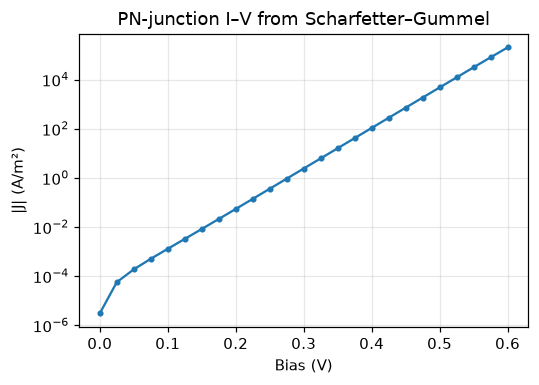

|J| spans 3.08e-06 → 2.04e+05 A/m²


In [3]:

biases = np.linspace(0.0, 0.6, 25)
I = sg_iv(step(1e22), biases)
plt.figure(figsize=(5,3.6))
plt.semilogy(biases, np.abs(I), "o-", ms=3)
plt.xlabel("Bias (V)"); plt.ylabel("|J| (A/m²)")
plt.title("PN-junction I–V from Scharfetter–Gummel")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"|J| spans {np.abs(I).min():.2e} → {np.abs(I).max():.2e} A/m²")


## Ideality factor
From the exponential region, $n=\frac{1}{V_T}\,dV/d(\ln J)$ should be ≈1 for an ideal diffusion-limited diode.

In [4]:

mask = (biases > 0.15) & (biases < 0.45)
lnJ = np.log(np.abs(I[mask]))
slope = np.polyfit(biases[mask], lnJ, 1)[0]
ideality = 1.0/(VT*slope)
print(f"Extracted ideality factor n = {ideality:.3f}")


Extracted ideality factor n = 1.019
